# Ray API sketch

This notebook is a user-facing sketch of the first-pass ray and imaging API.

The camera and domain-seeding sections below are real code. There is also one current internal single-ray walk on the spherical sample tree. The later public batch traversal and rendering sections are still API sketch only.

Design intent:
- exact per-cell `t_enter` and `t_exit` in physical `xyz`
- traversal operates directly on adaptive octree cells
- spherical trees still trace rays in `xyz`
- image formation stays layered above traversal


## Build the existing octree pieces

The new ray layer sits on top of the current `Octree` and `OctreeInterpolator`.


In [1]:
from batread import Dataset
import numpy as np

from batcamp import Octree
from batcamp import OctreeInterpolator

ds = Dataset.from_file("../sample_data/3d__var_1_n00000000.plt")

tree = Octree(
    points=ds[["X [R]", "Y [R]", "Z [R]"]],
    corners=ds.corners,
)

rho = ds["Rho [g/cm^3]"]
interp = OctreeInterpolator(tree, values=rho)

tree, interp


(<batcamp.octree.Octree at 0x1270438c0>,
 <batcamp.interpolator.OctreeInterpolator at 0x14f3b0d70>)

## Define a camera

For the first pass, the camera surface is just one function returning two arrays:

- `origins`
- `directions`

Both have shape `(ny, nx, 3)`.


In [2]:
from batcamp import camera_rays

camera_origin = np.array([-60.0, 0.0, 0.0])
camera_target = np.array([0.0, 0.0, 0.0])
camera_up = np.array([0.0, 0.0, 1.0])

origins, directions = camera_rays(
    origin=camera_origin,
    target=camera_target,
    up=camera_up,
    nx=11,
    ny=9,
    width=48.0,
    height=36.0,
    projection="parallel",
)

origins.shape, directions.shape


((9, 11, 3), (9, 11, 3))

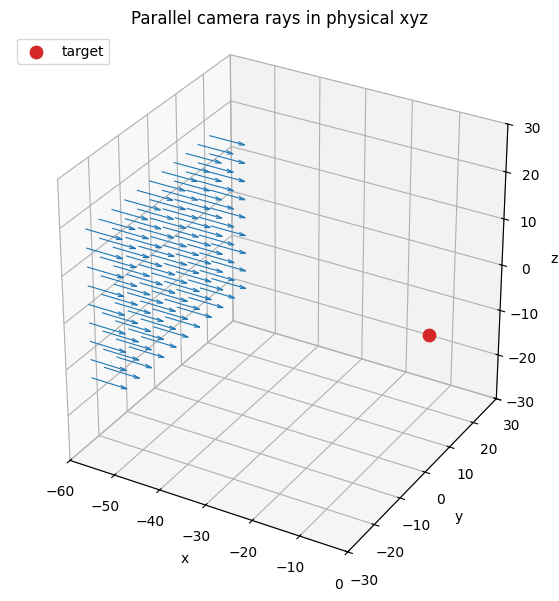

In [3]:
import matplotlib.pyplot as plt

tail = 8.0
origins_flat = origins.reshape(-1, 3)
directions_flat = directions.reshape(-1, 3)
tips_flat = origins_flat + tail * directions_flat

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.quiver(
    origins_flat[:, 0],
    origins_flat[:, 1],
    origins_flat[:, 2],
    directions_flat[:, 0],
    directions_flat[:, 1],
    directions_flat[:, 2],
    length=tail,
    normalize=False,
    arrow_length_ratio=0.18,
    linewidth=0.8,
    color="tab:blue",
)
ax.scatter(
    [camera_target[0]],
    [camera_target[1]],
    [camera_target[2]],
    color="tab:red",
    s=80,
    label="target",
)

all_points = np.vstack((origins_flat, tips_flat, camera_target.reshape(1, 3)))
mins = all_points.min(axis=0)
maxs = all_points.max(axis=0)
span = np.maximum(maxs - mins, 1.0)
center = 0.5 * (mins + maxs)
radius = 0.5 * float(np.max(span))
ax.set_xlim(center[0] - radius, center[0] + radius)
ax.set_ylim(center[1] - radius, center[1] + radius)
ax.set_zlim(center[2] - radius, center[2] + radius)
ax.set_box_aspect((1.0, 1.0, 1.0))
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Parallel camera rays in physical xyz")
ax.legend(loc="upper left")
plt.show()


## Seed rays inside the octree domain

The first implemented tracer pass only returns one seed point per ray inside the global octree domain.

For the spherical sample tree above, this uses the front visible shell only: once a forward ray hits the opaque inner boundary, the ray is finished.


In [4]:
from batcamp import OctreeRayTracer

tracer = OctreeRayTracer(tree)
seed_xyz = tracer.seed_domain(origins, directions, t_min=0.0, t_max=np.inf)

seed_xyz.shape


(9, 11, 3)

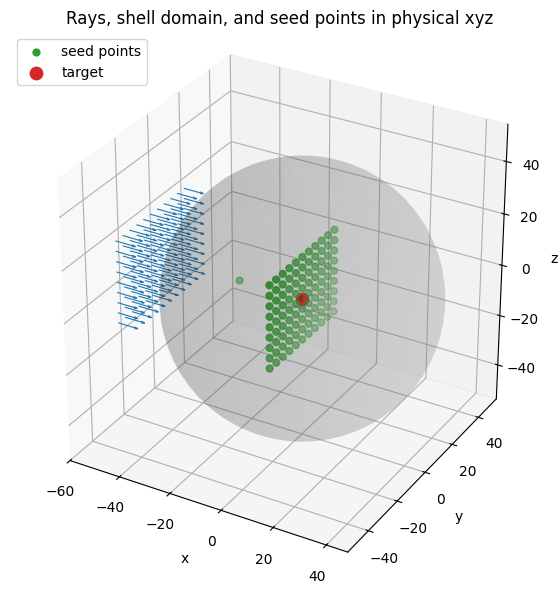

In [5]:
rpa_lo, rpa_hi = tree.domain_bounds(coord="rpa")
r_inner = float(rpa_lo[0])
r_outer = float(rpa_hi[0])

seed_flat = seed_xyz.reshape(-1, 3)
seed_mask = np.isfinite(seed_flat).all(axis=1)

azimuth = np.linspace(0.0, 2.0 * np.pi, 80)
polar = np.linspace(0.0, np.pi, 40)
azimuth_grid, polar_grid = np.meshgrid(azimuth, polar, indexing="xy")

def sphere_xyz(radius):
    x = radius * np.sin(polar_grid) * np.cos(azimuth_grid)
    y = radius * np.sin(polar_grid) * np.sin(azimuth_grid)
    z = radius * np.cos(polar_grid)
    return x, y, z

outer_x, outer_y, outer_z = sphere_xyz(r_outer)
inner_x, inner_y, inner_z = sphere_xyz(r_inner)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(outer_x, outer_y, outer_z, color="tab:gray", alpha=0.15, linewidth=0.0)
ax.plot_surface(inner_x, inner_y, inner_z, color="tab:orange", alpha=0.45, linewidth=0.0)
ax.quiver(
    origins_flat[:, 0],
    origins_flat[:, 1],
    origins_flat[:, 2],
    directions_flat[:, 0],
    directions_flat[:, 1],
    directions_flat[:, 2],
    length=tail,
    normalize=False,
    arrow_length_ratio=0.18,
    linewidth=0.8,
    color="tab:blue",
)
ax.scatter(
    seed_flat[seed_mask, 0],
    seed_flat[seed_mask, 1],
    seed_flat[seed_mask, 2],
    color="tab:green",
    s=24,
    label="seed points",
)
ax.scatter(
    [camera_target[0]],
    [camera_target[1]],
    [camera_target[2]],
    color="tab:red",
    s=80,
    label="target",
)

sphere_points = np.column_stack((outer_x.reshape(-1), outer_y.reshape(-1), outer_z.reshape(-1)))
all_points = np.vstack((origins_flat, tips_flat, seed_flat[seed_mask], sphere_points))
mins = all_points.min(axis=0)
maxs = all_points.max(axis=0)
span = np.maximum(maxs - mins, 1.0)
center = 0.5 * (mins + maxs)
radius = 0.5 * float(np.max(span))
ax.set_xlim(center[0] - radius, center[0] + radius)
ax.set_ylim(center[1] - radius, center[1] + radius)
ax.set_zlim(center[2] - radius, center[2] + radius)
ax.set_box_aspect((1.0, 1.0, 1.0))
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Rays, shell domain, and seed points in physical xyz")
ax.legend(loc="upper left")
plt.show()


## Trace one spherical ray

The current walker is still internal, but it can now trace one real forward ray on the spherical sample tree.

This first pass starts from the seeded leaf and walks forward to the opaque inner boundary. The later public `trace(...)` method should generalize this to seeded batched traversal in both directions.


In [6]:
single_origin = np.array([-60.0, 0.5, 0.25], dtype=float)
single_direction = np.array([1.0, 0.0, 0.0], dtype=float)
single_seed = tracer.seed_domain(single_origin, single_direction)
start_leaf_id = int(tree.lookup_points(single_seed, coord="xyz")[0])

leaf_ids, t_enter, t_exit = tracer._trace_one_ray(
    start_leaf_id,
    single_origin,
    single_direction,
)
segment_length = t_exit - t_enter

single_seed, leaf_ids[:6], t_enter[:6], t_exit[:6], segment_length[:6]


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


(array([[-24.49362194,   0.5       ,   0.25      ]]),
 array([5685, 5684, 5683, 5682, 5591, 5590]),
 array([30.44827931, 36.79939909, 41.78896761, 45.70886953, 48.78842853,
        51.2078844 ]),
 array([36.79939909, 41.78896761, 45.70886953, 48.78842853, 51.2078844 ,
        53.10856849]),
 array([6.35111978, 4.98956851, 3.91990192, 3.079559  , 2.41945587,
        1.90068409]))

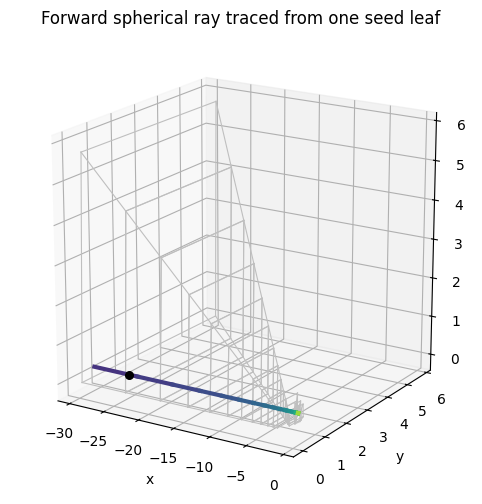

In [7]:
corner_bits = np.array(
    [
        [0, 1, 0],
        [1, 1, 0],
        [1, 1, 1],
        [0, 1, 1],
        [0, 0, 0],
        [1, 0, 0],
        [1, 0, 1],
        [0, 0, 1],
    ],
    dtype=np.int8,
)
edge_pairs = []
for i in range(8):
    for j in range(i + 1, 8):
        if np.count_nonzero(corner_bits[i] != corner_bits[j]) == 1:
            edge_pairs.append((i, j))

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(projection="3d")
colors = plt.cm.viridis(np.linspace(0.15, 0.85, leaf_ids.size))

for cell_id in leaf_ids:
    cell_xyz = tree.cell_points(int(cell_id))
    for i0, i1 in edge_pairs:
        edge_xyz = cell_xyz[[i0, i1]]
        ax.plot(edge_xyz[:, 0], edge_xyz[:, 1], edge_xyz[:, 2], color="0.75", linewidth=0.8)

ray_t = np.array([t_enter[0], t_exit[-1]], dtype=float)
ray_xyz = single_origin[None, :] + ray_t[:, None] * single_direction[None, :]
ax.plot(ray_xyz[:, 0], ray_xyz[:, 1], ray_xyz[:, 2], color="black", linewidth=1.2, linestyle="--")
ax.scatter(single_seed[0, 0], single_seed[0, 1], single_seed[0, 2], color="black", s=30)

for color, t0, t1 in zip(colors, t_enter, t_exit):
    seg_t = np.array([t0, t1], dtype=float)
    seg_xyz = single_origin[None, :] + seg_t[:, None] * single_direction[None, :]
    ax.plot(seg_xyz[:, 0], seg_xyz[:, 1], seg_xyz[:, 2], color=color, linewidth=3)

ax.set_title("Forward spherical ray traced from one seed leaf")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_box_aspect((1.0, 1.0, 1.0))
ax.view_init(elev=18, azim=-58)
plt.show()


## Trace adaptive octree segments

This is still sketch only. The intended later surface is:

```python
segments = tracer.trace(origins, directions, seed_xyz=seed_xyz, t_min=0.0, t_max=np.inf)

segments.ray_offsets.shape
segments.cell_ids.shape
segments.t_enter.shape
segments.t_exit.shape
```

The key result there will be exact per-cell `t_enter` and `t_exit` in physical `xyz`, with no iterative probing or pseudo-marching.


## Render a first image

A single opinionated helper is enough for the first pass:

```python
from batcamp import render_midpoint_image

image = render_midpoint_image(
    interpolator=interp,
    segments=segments,
)

image.shape
```


## Low-level contract

The minimal public surface this sketch assumes is:

- `camera_rays(...)`
- `OctreeRayTracer.seed_domain(...)` returning `seed_xyz`
- later: `OctreeRayTracer.trace(...)`
- later: packed segment arrays with `ray_offsets`, `cell_ids`, `t_enter`, `t_exit`
- later: `render_midpoint_image(...)`

Everything beyond domain seeding can stay private until the first deterministic traversal implementation is working.
